<a href="https://colab.research.google.com/github/CeZa18/ITAI-1371-ML-Labs/blob/main/L09_CesarZaldivar_ITAI1370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 09 Lab - Ensemble Methods
**Objective:** To learn how to use **ensemble methods**, which combine the predictions of several individual models to produce a final prediction that is more accurate and robust than any of the individual models alone.
**In this lab, you will train and compare a single Decision Tree against a powerful ensemble method, the Random Forest.**

## Part 1: The Wisdom of the Crowd
**Concept:** The core idea behind ensemble methods is the "wisdom of the crowd." If you ask one person a difficult question, they might be wrong. But if you ask a large, diverse group of people the same question and average their answers, the result is often surprisingly accurate.
Ensemble methods apply this to machine learning. Instead of relying on a single model, we build a "committee" of models and have them vote on the final prediction.
Two popular ensemble techniques:
*   **Bagging (Bootstrap Aggregating):** Trains multiple models (e.g., Decision Trees) on different random subsets of the training data. The **Random Forest** is the most famous example.
*   **Boosting:** Trains models sequentially, where each new model focuses on correcting the errors made by the previous one. Examples include Gradient Boosting and AdaBoost.

## Part 2: Setup
We will use the Iris dataset to classify flower species.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Part 3: A Single Decision Tree
A single Decision Tree is prone to overfitting. It can create very specific rules that match the training data perfectly but don't generalize well.
**Your Task:** Train a single `DecisionTreeClassifier` and evaluate its accuracy.

In [2]:
# --- ENTER YOUR CODE HERE ---

# 1. Create and train a single Decision Tree
single_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
single_tree.fit(X_train, y_train)

# 2. Make predictions and evaluate its accuracy
y_pred_tree = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Accuracy of a single Decision Tree: {accuracy_tree:.2%}")

Accuracy of a single Decision Tree: 97.78%


## Part 4: The Random Forest Ensemble
**Concept:** A Random Forest is an ensemble of many Decision Trees. It builds hundreds of trees, each trained on a random subset of the data and using a random subset of the features. To make a prediction, it gets a vote from every tree in the "forest" and chooses the class that gets the most votes.
This process of averaging the votes of many diverse trees makes the Random Forest much more robust and less prone to overfitting than a single tree.
**Your Task:** Train a `RandomForestClassifier` and compare its accuracy to the single tree.

In [3]:
# --- ENTER YOUR CODE HERE ---

# 1. Create and train a Random Forest
# random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
random_forest.fit(X_train, y_train)

# 2. Make predictions and evaluate its accuracy
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# 3. Check the model's accuracy
print(f"Accuracy of the Random Forest: {accuracy_rf:.2%}")

Accuracy of the Random Forest: 100.00%


## Part 5: Feature Importance
**Concept:** A great benefit of tree-based ensembles like Random Forest is that they can tell you which features were most important for making accurate predictions.
**Your Task:** Extract and plot the feature importances from your trained Random Forest model.

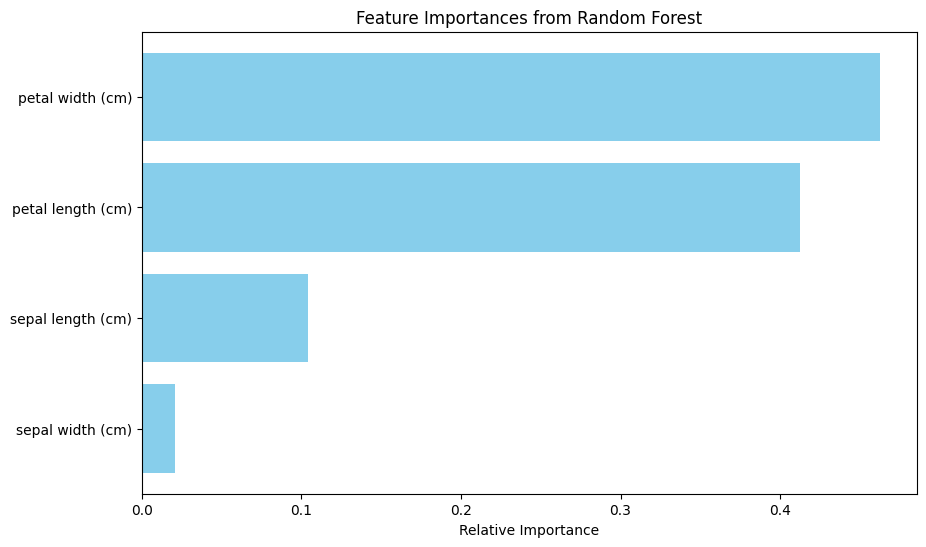

In [4]:
import matplotlib.pyplot as plt
import numpy as np
# --- ENTER YOUR CODE HERE ---
# 1. Get the feature importances from the trained Random Forest model
importances = random_forest.feature_importances_

# 2. Create a bar plot to visualize them
feature_names = iris.feature_names
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title("Feature Importances from Random Forest")
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [5]:
# Proof why the petal width and lenght are the two most important features

# Create a dataframe
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

# Calculate the mean of each feature for each species
species_means = df.groupby('species').mean()

# Map the numeric target back to names
species_means.index = iris.target_names

# Display the results
print(species_means)

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
setosa                 0.246  
versicolor             1.326  
virginica              2.026  


## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.
1.  **In your own words, what is the main idea behind ensemble methods? Why is a "committee" of models often better than a single expert model?**
2.  **Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?**
3.  **Looking at the feature importance plot, which two features were most important for classifying the iris flowers?** Does this match what you might expect from your own knowledge of flowers?

**[ENTER YOUR ANSWERS HERE]**

1. In the **ensemble method** the models cover for each other's weaknesses. The commitiee apporach works by voting the correct responses so that it cancels errors out. Whereas the **single "expert" model** has blind spots that given high variance it can tend to overreact to noise.

2. As I expected, the **Random Forest** performed better in this test even with a limitation of `max_depth=2` due to the ensemble's voting mechanism.

3. The two most important features were the **petal width** and **petal length** doing most of the heavy lifting in identifying the three flower species. To prove that mathematically I ran an analysis of the mean and mode of the petal width and length for each of the species.
    * The data showed that for the sepal width/length, the means between _Versicolor_ and _Virginica_ will be almost the same, meaning that a single split will struggle to separate them perfectly.
    * For petal length and width, we observe massive jumps between the species (e.g. _Setosa_ petal length mean is ~1.46cm, while _Versicolor_ is ~4.26cm, and _Virginica_ is ~5.55cm). This statistical gap proves why the tree targets them first.